Alumna: Castillo Dorantes Sandra Geraldine

## Sesion 11 - Ejercicio final

Construye una gráfica propia que responda una pregunta de negocio. Debe cumplir:

1. Título interpretativo.
2. Ejes claros y con unidades.
3. Categorías ordenadas cuando aplique.
4. Uso intencional del color.
5. Una conclusión escrita.

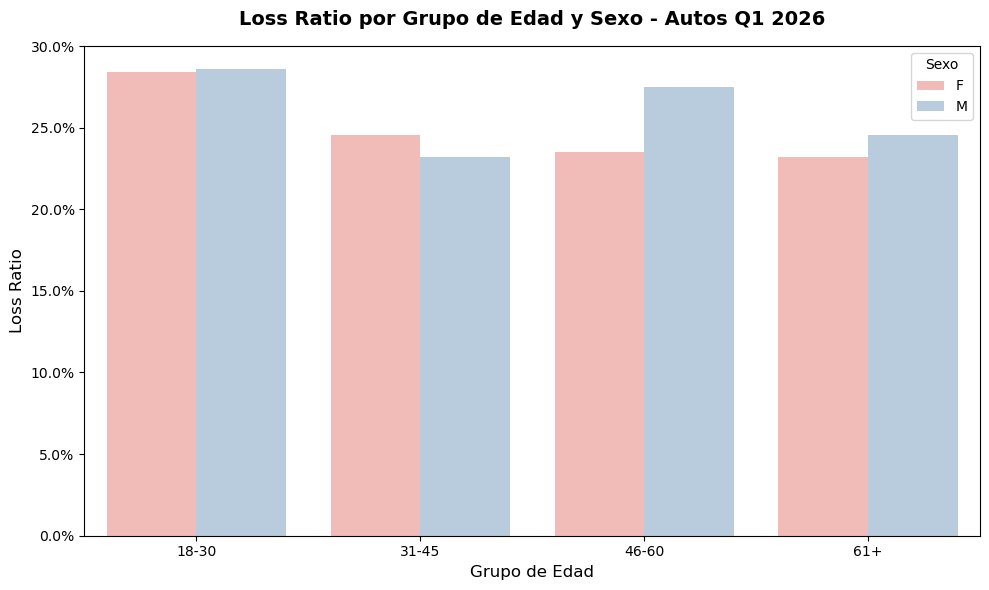

In [ ]:
# ======================================
#              PREGUNTA
# ======================================
# ¿Cómo influye la edad y el género del asegurado en el riesgo de siniestro en el ramo de Autos?

# Librerias
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import seaborn as sns

# Carga de archivos
ruta = "C:/Users/HP/diplomado-ml-seguros/Modulo_1/sesion_10/datos"
df = pd.read_parquet(ruta + "/cartera_q1_2026_final.parquet")

# Filtramos el dataframe solo por el ramo de autos
a = df[df['ramo'] == 'Autos'].copy()
# Creamos la variable con el grupo de edad: g_edad
a["g_edad"] = pd.cut(
    a["edad"],
    bins=[0, 30, 45, 60, 100],
    labels=["18-30", "31-45", "46-60", "61+"])

# Agrupamos las variables que necesitamos: sexo y g_edad
agrupado = a.groupby(['g_edad', 'sexo'], 
                     observed=False)[['monto_pagado', 'prima_total']].sum().reset_index()
# Calculamos el loss_ratio
agrupado['loss_ratio'] = agrupado['monto_pagado'] / agrupado ['prima_total']

# ======================================
#              GRAFICO
# ======================================

orden_columnas = ["18-30", "31-45", "46-60", "61+"]
plt.figure(figsize=(10, 6))

# Creamos el gráfico de barras agrupado
sns.barplot(
    data=agrupado,
    x="g_edad",
    y="loss_ratio", 
    hue="sexo", 
    palette="Pastel1",
    order=orden_columnas,
)

# Titulos, etiquetas y leyendas
plt.title(
    "Loss Ratio por Grupo de Edad y Sexo - Autos Q1 2026",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Grupo de Edad", fontsize=12)
plt.ylabel("Loss Ratio", fontsize=12)
plt.legend(title="Sexo", loc="upper right")

# Eje Y en porcentajes
ax = plt.gca()
ax.yaxis.set_major_formatter(
    ticker.PercentFormatter(1.0)
)

plt.tight_layout()
plt.show()

# ======================================
#              Conclusion
# ======================================

# La grafica nos muestra que el ramo de Autos tiene un Loss Ratio menor al 30%.
# Así mismo, podemos ver que el grupo de edad con mayor siniestralidad es el grupo
# de 18-30 años, lo cual podría tener sentido considerando que son personas jóvenes,
# con mas inexperiencia al conducir. Por otro lado, en la mayoría de grupos los 
# hombres son los que mas Loss Ratio presentan, pero especificamente en el grupo
# de 31-45 años las mujeres son las que muestran un porcentaje mayor. El grupo de
# edad siguiente (46-60 años) muestra un aumento considerable del Loss Ratio en 
# hombres, en contraste de los demás grupos que la diferencia de Loss Ratio entre 
# sexos no parece ser tan significativa.
# Respondiendo a la pregunta, el sexo sí parece ser un factor que influya en el
# Loss Ratio, pero no de la misma forma en cada grupo de edad. Como se ha mencionado
# anteriormente, la diferencia más grande por sexo es en el grupo de 46-60 años. 
# Adicionalmente, la edad tambien implica un mayor o menor Loss Ratio, pues el grupo 
# más joven presenta un mayor Loss Ratio de forma notable.